https://colab.research.google.com/drive/1QW1KJV7PCIE2d2ftvAej_fQ-TkV8lRRz?usp=sharing

# **Cardiac Diagnostics Case Study**

## Project Objective

The goal of this project is to build a machine learning model that can predict the presence of heart disease using patient health information. By analyzing medical attributes such as age, cholesterol level, blood pressure, and heart rate, the model can help identify patients who may be at risk of heart disease.

## **Importing Libraries :**

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [10]:
df = pd.read_csv("/content/drive/MyDrive/Data Science Course/DATASETS/heart.csv")

df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [11]:
df.shape

(303, 14)

In [12]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [14]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


Missing Values:

In [15]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


No Missing value found.

Duplicate values :

In [16]:
df.duplicated().sum()

np.int64(1)

1 duplicate value found.

In [18]:
# Remove duplicate records
df.drop_duplicates(inplace=True)

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


I found 1 duplicate record in the dataset. Since duplicate rows can affect the model's learning, I removed it before training the models.

The dataset contains patient medical information such as age, cholesterol, blood pressure and heart rate. I checked the dataset for missing values and duplicate records before starting the analysis.

### **Exploratory Data Analysis (EDA) :**

Target Variable Distribution :

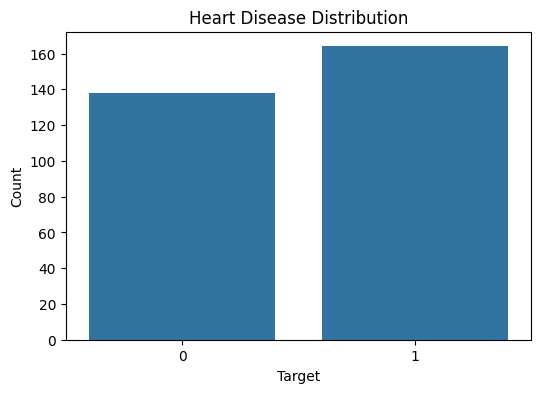

target
1    164
0    138
Name: count, dtype: int64


In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x='target', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

print(df["target"].value_counts())

The dataset is fairly balanced, with 164 patients having heart disease and 138 patients without heart disease. Since both classes are well represented, the models are less likely to be biased toward one class.

**Correlation Heatmap :**

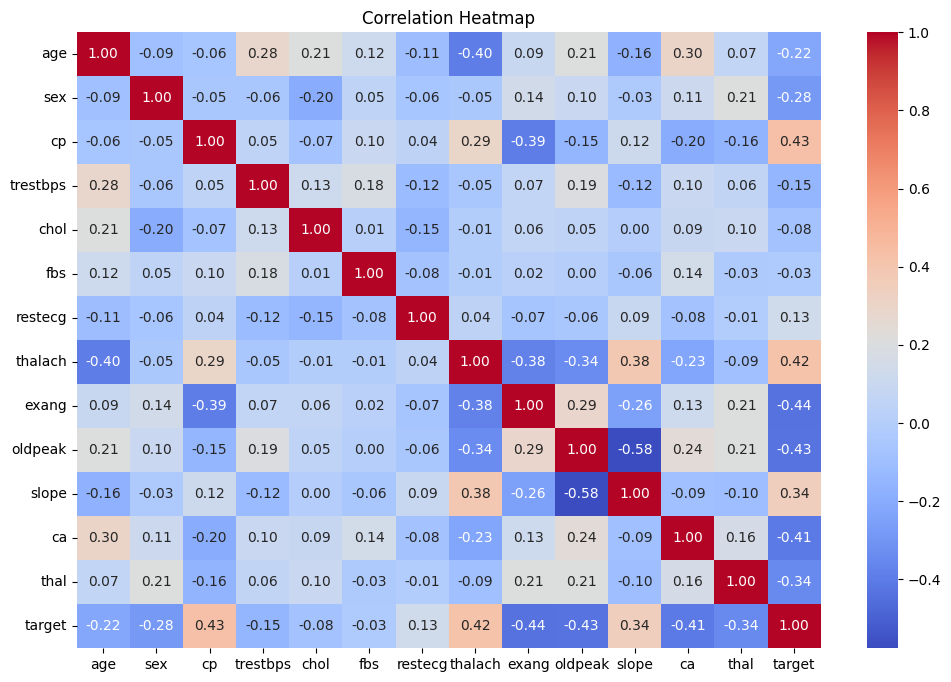

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

The heatmap shows that chest pain type (cp), maximum heart rate (thalach) and slope have a positive relationship with the target. On the other hand, exercise-induced angina (exang), oldpeak and the number of major vessels (ca) have a negative relationship with the target. These features are likely to be important for prediction.

**Age Distribution :**

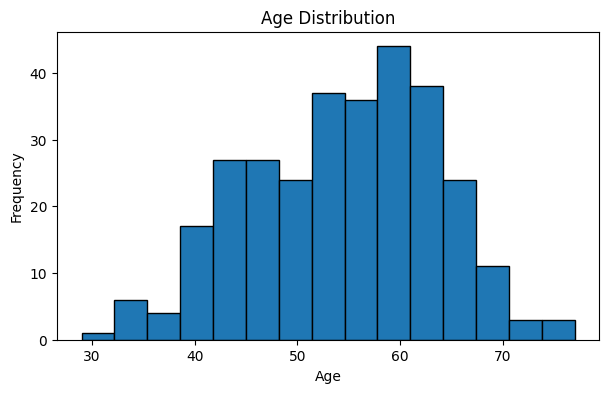

In [21]:
plt.figure(figsize=(7,4))

plt.hist(df["age"], bins=15, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Most patients in the dataset are between 50 and 65 years of age. There are fewer younger and older patients.

**Cholesterol Distribution :**

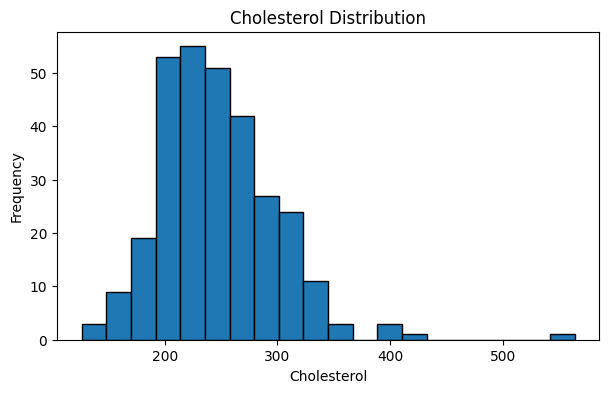

In [22]:
plt.figure(figsize=(7,4))

plt.hist(df["chol"], bins=20, edgecolor="black")

plt.title("Cholesterol Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

Most patients have cholesterol values between 180 and 300. A few patients have very high cholesterol values, which appear as outliers.

**Boxplots (Outlier Detection) :**

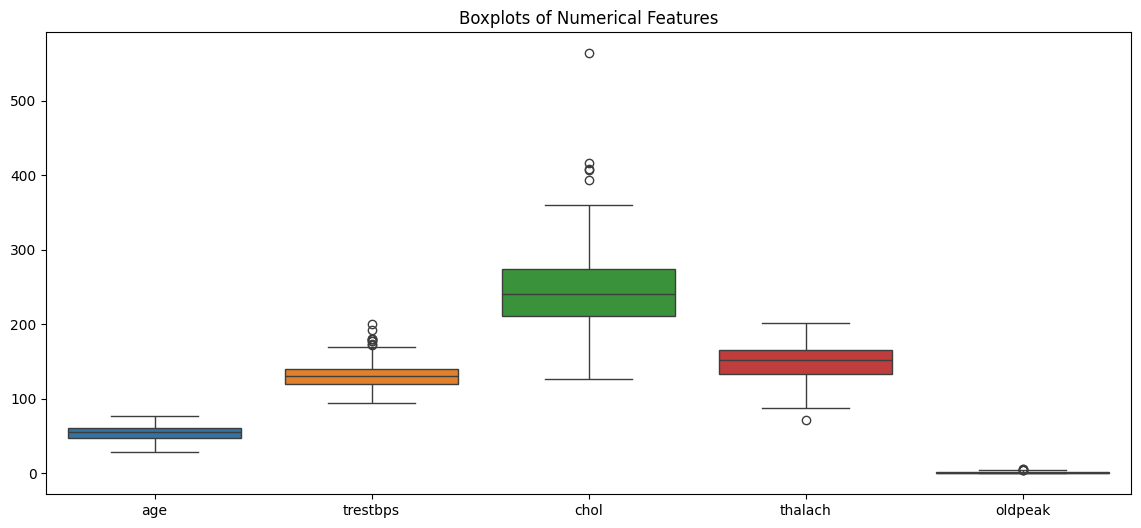

In [24]:
plt.figure(figsize=(14,6))

sns.boxplot(data=df[['age','trestbps','chol','thalach','oldpeak']])

plt.title("Boxplots of Numerical Features")

plt.show()

The boxplots show a few outliers, especially in cholesterol and resting blood pressure. Since these values may represent actual patient measurements, I will keep them instead of removing them.

### Observation

Although a few outliers are present, especially in cholesterol and resting blood pressure, they appear to be realistic medical values. Therefore, I decided to keep them instead of removing them.

**Heart Disease by Gender :**

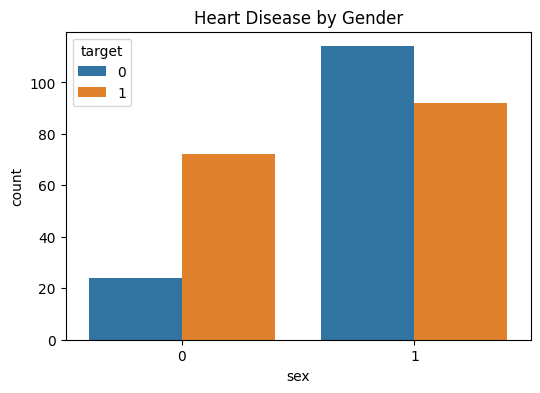

In [25]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', hue='target', data=df)

plt.title("Heart Disease by Gender")

plt.show()

The target variable is fairly balanced, with 165 patients having heart disease and 138 patients not having heart disease. Since both classes are well represented, the dataset is suitable for classification and the model is less likely to be biased toward a single class.

In [26]:
(df["target"].value_counts(normalize=True) * 100).round(2)

,proportion
target,
1,54.3
0,45.7


# **Feature Selection :**

In [27]:
# Features
X = df.drop("target", axis=1)

# Target
y = df["target"]

print(X.shape)
print(y.shape)

(302, 13)
(302,)


## **Train-Test Split :**

The dataset is divided into training and testing sets. The training data is used to train the models, while the testing data is used to evaluate their performance.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Records:", len(X_train))
print("Testing Records :", len(X_test))

Training Records: 241
Testing Records : 61


Why stratify=y?

Because our target has two classes:

Heart Disease and
No Heart Disease

stratify keeps the same proportion of both classes in train and test.

## **Feature Scaling :**

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

I used StandardScaler to standardize the features. The scaler was fitted only on the training data to avoid data leakage, and the same transformation was applied to the testing data.

# **Logistic Regression :**

Logistic Regression is a classification algorithm used to predict whether a patient has heart disease or not.

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [31]:
y_pred_lr = lr.predict(X_test_scaled)

In [32]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 0.7868852459016393
Precision: 0.7631578947368421
Recall   : 0.8787878787878788
F1 Score : 0.8169014084507042


[[19  9]
 [ 4 29]]


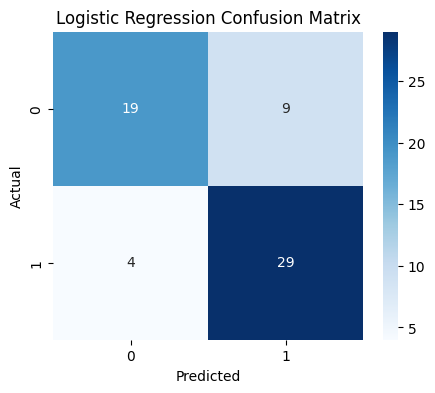

In [35]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)
print(cm)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [34]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.83      0.68      0.75        28
           1       0.76      0.88      0.82        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.78        61



The Logistic Regression model achieved an accuracy of about 79%. It also produced a high recall score, which means it correctly identified most patients with heart disease. Since this is a medical prediction problem, a higher recall is important because missing a patient with heart disease can be risky.

## **HyperTuning :**

In [36]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "max_iter": [100, 200, 500]
}

In [37]:
grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'max_iter': [100, 200, 500],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [38]:
print("Best Parameters:", grid_lr.best_params_)
print("Best CV Score:", grid_lr.best_score_)

Best Parameters: {'C': 100, 'max_iter': 100, 'solver': 'lbfgs'}
Best CV Score: 0.8301020408163267


In [39]:
best_lr = grid_lr.best_estimator_

y_pred_best_lr = best_lr.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_best_lr))
print("Precision:", precision_score(y_test, y_pred_best_lr))
print("Recall   :", recall_score(y_test, y_pred_best_lr))
print("F1 Score :", f1_score(y_test, y_pred_best_lr))

Accuracy : 0.7868852459016393
Precision: 0.7631578947368421
Recall   : 0.8787878787878788
F1 Score : 0.8169014084507042


### Observation

GridSearchCV selected the best hyperparameters automatically. However, the evaluation metrics remained almost the same as the basic Logistic Regression model. This suggests that the default model was already performing close to its best on this dataset.

# **K-Nearest Neighbors (KNN) :**

KNN classifies a patient based on the majority class of its nearest neighbors. Since KNN is a distance-based algorithm, feature scaling is required.

Basic KNN :

In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [42]:
y_pred_knn = knn.predict(X_test_scaled)

In [43]:
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

Accuracy : 0.8032786885245902
Precision: 0.7692307692307693
Recall   : 0.9090909090909091
F1 Score : 0.8333333333333334


[[19  9]
 [ 3 30]]


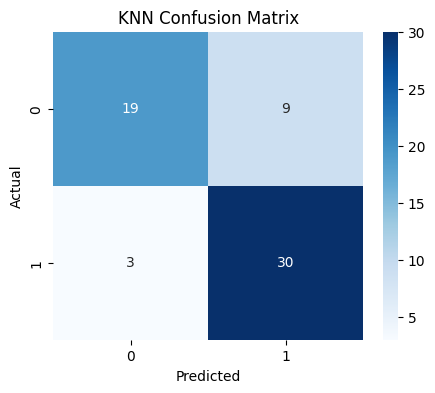

In [46]:
cm = confusion_matrix(y_test, y_pred_knn)

print(cm)
plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [45]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.86      0.68      0.76        28
           1       0.77      0.91      0.83        33

    accuracy                           0.80        61
   macro avg       0.82      0.79      0.80        61
weighted avg       0.81      0.80      0.80        61



Current results:

| Model               |  Accuracy | Precision |    Recall |        F1 |
| ------------------- | --------: | --------: | --------: | --------: |
| Logistic Regression |     0.787 |     0.763 |     0.879 |     0.817 |
| **KNN (Default)**   | **0.803** | **0.769** | **0.909** | **0.833** |


### Observation

The basic KNN model performed slightly better than Logistic Regression. It achieved higher accuracy and recall, which means it correctly identified more patients with heart disease.

# **Decision Tree :**

Decision Tree classifies data by creating a series of decision rules. It is easy to understand and can capture non-linear relationships in the data.

In [58]:
#Basic Model

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [59]:
y_pred_dt = dt.predict(X_test)

In [60]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))

Accuracy : 0.7213114754098361
Precision: 0.7105263157894737
Recall   : 0.8181818181818182
F1 Score : 0.7605633802816901


[[17 11]
 [ 6 27]]


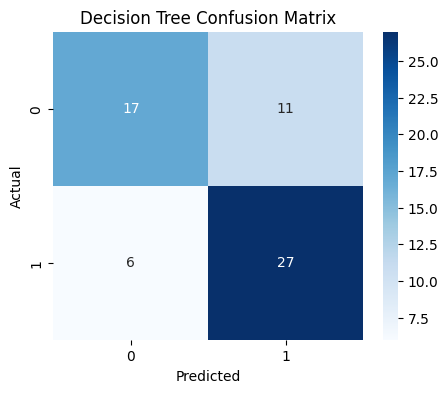

In [63]:
cm = confusion_matrix(y_test, y_pred_dt)
print(cm)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [62]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.74      0.61      0.67        28
           1       0.71      0.82      0.76        33

    accuracy                           0.72        61
   macro avg       0.72      0.71      0.71        61
weighted avg       0.72      0.72      0.72        61



### Observation

The basic Decision Tree model achieved lower accuracy than Logistic Regression and KNN. This may be because the tree overfits the training data when no restrictions are applied. Hyperparameter tuning will be used to control the tree size and improve its performance.

### **Hyperparameter Tuning :**

In [64]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10]
}

In [65]:
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [66]:
print("Best Parameters:", grid_dt.best_params_)
print("Best CV Score:", grid_dt.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Best CV Score: 0.7845238095238095


In [67]:
best_dt = grid_dt.best_estimator_

y_pred_best_dt = best_dt.predict(X_test)

In [68]:
print("Accuracy :", accuracy_score(y_test, y_pred_best_dt))
print("Precision:", precision_score(y_test, y_pred_best_dt))
print("Recall   :", recall_score(y_test, y_pred_best_dt))
print("F1 Score :", f1_score(y_test, y_pred_best_dt))

Accuracy : 0.7868852459016393
Precision: 0.7631578947368421
Recall   : 0.8787878787878788
F1 Score : 0.8169014084507042


### Observation

The tuned Decision Tree performed much better than the default model. Limiting the tree depth to 3 reduced overfitting and improved the model's performance on the test data. This shows that hyperparameter tuning can help create a simpler and more effective model.

Current Leaderboard :

| Model                 |   Accuracy |     Recall |         F1 |
| --------------------- | ---------: | ---------: | ---------: |
| Logistic Regression   |     78.69% |     87.88% |     81.69% |
| KNN                   | **80.33%** | **90.91%** | **83.33%** |
| Decision Tree (Tuned) |     78.69% |     87.88% |     81.69% |


# **Random Forest :**

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees. It reduces overfitting and usually provides better prediction performance than a single Decision Tree.

In [69]:
#Basic Model

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [70]:
y_pred_rf = rf.predict(X_test)

In [71]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.7868852459016393
Precision: 0.75
Recall   : 0.9090909090909091
F1 Score : 0.821917808219178


[[18 10]
 [ 3 30]]


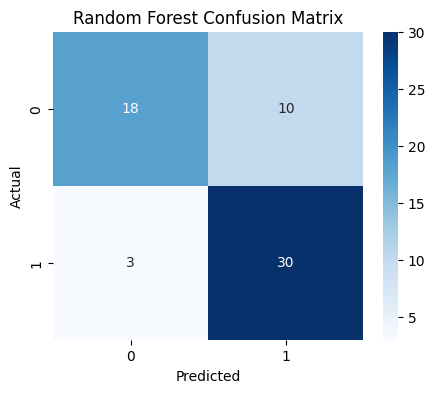

In [73]:
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

### Observation

The Random Forest model performed well and achieved a high recall score, correctly identifying most patients with heart disease. Compared to the Decision Tree, the ensemble approach helped produce more stable predictions.

### **Hyperparameter Tuning :**

In [74]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 10, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy')

In [75]:
print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.8551020408163265


In [76]:
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_best_rf))
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall   :", recall_score(y_test, y_pred_best_rf))
print("F1 Score :", f1_score(y_test, y_pred_best_rf))

Accuracy : 0.8032786885245902
Precision: 0.7560975609756098
Recall   : 0.9393939393939394
F1 Score : 0.8378378378378378


### Observation

After hyperparameter tuning, the Random Forest model achieved better performance than the default model. Increasing the number of trees and limiting the maximum depth helped improve the model while reducing overfitting. The tuned model also achieved the highest recall, correctly identifying most patients with heart disease.

| Model                        |   Accuracy | Precision |     Recall |         F1 |
| ---------------------------- | ---------: | --------: | ---------: | ---------: |
| Logistic Regression (Tuned)  |     78.69% |    76.32% |     87.88% |     81.69% |
| KNN                          |     80.33% |    76.92% |     90.91% |     83.33% |
| Decision Tree (Tuned)        |     78.69% |    76.32% |     87.88% |     81.69% |
| **Random Forest (Tuned)** (on Lead) | **80.33%** |    75.61% | **93.94%** | **83.78%** |


# **SVM**

In [77]:
from sklearn.svm import SVC

svm = SVC(random_state=42)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

Accuracy : 0.8360655737704918
Precision: 0.7948717948717948
Recall   : 0.9393939393939394
F1 Score : 0.8611111111111112


### Observation

The SVM model achieved the best overall performance among all the models. It produced the highest accuracy and F1-score while also maintaining a high recall. This indicates that SVM was able to classify patients more effectively than the other models on this dataset.

# **Final Comparision :**

In [78]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],

    "Accuracy":[
        0.7869,
        0.8033,
        0.7869,
        0.8033,
        0.8361
    ],

    "Precision":[
        0.7632,
        0.7692,
        0.7632,
        0.7561,
        0.7949
    ],

    "Recall":[
        0.8788,
        0.9091,
        0.8788,
        0.9394,
        0.9394
    ],

    "F1 Score":[
        0.8169,
        0.8333,
        0.8169,
        0.8378,
        0.8611
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7869,0.7632,0.8788,0.8169
1,KNN,0.8033,0.7692,0.9091,0.8333
2,Decision Tree,0.7869,0.7632,0.8788,0.8169
3,Random Forest,0.8033,0.7561,0.9394,0.8378
4,SVM,0.8361,0.7949,0.9394,0.8611


In [79]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print(best_model)

Model           SVM
Accuracy     0.8361
Precision    0.7949
Recall       0.9394
F1 Score     0.8611
Name: 4, dtype: object


### **Accuracy Comparision Graph :**

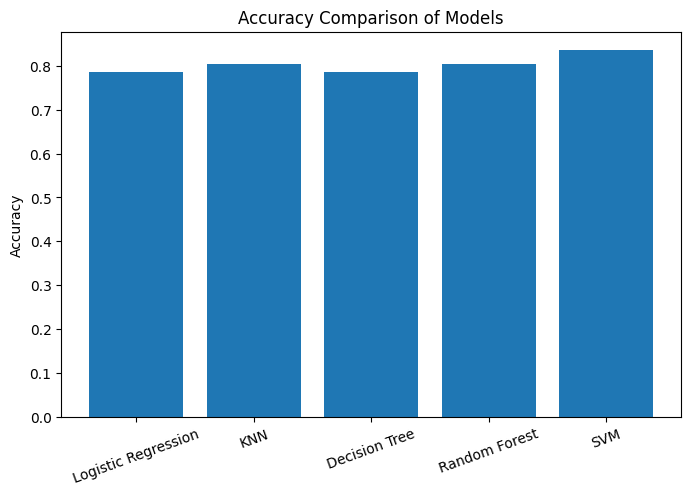

In [80]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["Accuracy"]
)

plt.xticks(rotation=20)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison of Models")

plt.show()

# Conclusion

In this project, I built and compared five classification models for predicting heart disease.

After preprocessing the data, I trained Logistic Regression, KNN, Decision Tree, Random Forest and SVM models. Hyperparameter tuning was applied to Logistic Regression, Decision Tree and Random Forest using GridSearchCV.

Among all the models, SVM achieved the best overall performance with an accuracy of **83.61%**, a recall of **93.94%**, and an F1-score of **86.11%**. This indicates that SVM was the most effective model for this dataset.

This project helped me understand the complete machine learning workflow, including data preprocessing, feature scaling, model training, hyperparameter tuning, model evaluation and comparison.